# Welcome to my Sentinels Valorant Data Analysis Project

I'll be taking a look data on the Sentinels Valorant Team across 2 different regional events, looking at statistics from custom datasets to look at what the team has struggled with, improved on, and seeing if changes they made were worth it  
For some context, the team came into 2026 losing most of their roster and introducing a couple of rookies, as well as 2 crucial role swaps that seemed to have defined their Kickoff. After they were knocked out of the tournament, they fired their coach Kaplan and made 2 roster moves sending away Kyu and N4rrate switching in-game leaders back to their original johnqt. The 2 replacements for Kyu and N4rrate were JonahP and tier-2 upcoming star Jerrwin.

In the beginning of 2026 at Americas Kickoff, the players and roles were as follows:  
- Duelist: N4RRATE
- Initiator: Kyu (igl)
- Sentinel: cortezia
- Controller / Secondary Duelist: reduxx
- Flex: johnqt

Then at the beginning of Stage 1, after switching out 2 players and more roles, it became:  
- Duelist: Jerrwin
- Initiator: JonahP
- Sentinel: cortezia
- Controller / Secondary Duelist: reduxx
- Flex: johnqt (igl)

### First, we'll take a look at our datasets below

Dataset 1: reg_players_kickoff.csv  
This dataset contains overall individual stats across all the players who participated in VCT Americas Kickoff: 2026  
This data was collected from the website url "https://www.vlr.gg/event/stats/2682/vct-2026-americas-kickoff"

Dataset 2: reg_players_s1.csv  
This dataset contains overall individual statistics across all the players who participated in VCT Americas Stage 1: 2026  
This data was also collected from the website url "https://www.vlr.gg/event/stats/2860/vct-2026-americas-stage-1"

Dataset 3: indi_by_series.csv  
This dataset contains individual statistics across different series for each of the Sentinels players across both Kickoff and Stage 1  
This data was collected via manual inputs from each series Sentinels participated in (9 series)

Dataset 4: reg_teams_kickoff.csv  
This dataset contains overall regional team statistics pertaining to round results / winrates  
This data was collected via manual inputs from "https://www.thespike.gg/valorant-stats/teams#event=3944"

Dataset 5: reg_teams_s1.csv  
This dataset is identical to Dataset 4, however is from "https://www.thespike.gg/valorant-stats/teams#event=4044"

Dataset 6: vod_review.csv  
This dataset contains round-by-round data collection by each individual on the Sentinels team, tracking every round, every map, and every series from Kickoff and Stage 1

Before we work with the datasets, we have to clean them, but before we clean them, we have to make some imports before we can have functional code!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from pathlib import Path

Dataset 1 + 2 Cleaning

In [2]:
def sen_indi_clean(input_path):
    df = pd.read_csv(input_path)
    
    df['cl_percent'] = df['cl_percent'].fillna(0)

    for col in ["kast", "hs_percent", "cl_percent"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("%", "", regex=False)
                .astype(float) / 100
            )

    numeric_cols = [
        "series_result", "rds_played", "rating", "acs", "kd", "kast", "adr", "kpr", "apr", "fk_fd_ratio", "fkpr", "fdpr", "hs_percent", "cl_percent"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

reg_players_kickoff_df = sen_indi_clean("raw_data/reg_players_kickoff.csv")
reg_players_s1_df = sen_indi_clean("raw_data/reg_players_s1.csv")

reg_players_kickoff_df.to_csv(Path("clean_data") / "reg_players_kickoff.csv", index=False)
reg_players_s1_df.to_csv(Path("clean_data") / "reg_players_s1.csv", index=False)

Dataset 3 Cleaning

In [3]:
def sen_series_clean(input_path):
    df = pd.read_csv(input_path)
    
    df['cl_percent'] = df['cl_percent'].fillna(0)

    for col in ["kast", "hs_percent", "cl_percent"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("%", "", regex=False)
                .astype(float) / 100
            )

    numeric_cols = [
        "series_result", "rds_played", "rating", "acs", "kd", "kast", "adr", "kpr", "apr", "fkpr", "fdpr", "hs_percent", "cl_percent"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

indi_by_series_df = sen_series_clean("raw_data/indi_by_series.csv")

indi_by_series_df.to_csv(Path("clean_data") / "indi_by_series.csv", index=False)

Dataset 4 + 5 Cleaning

In [4]:
def teams_clean(input_path):
    df = pd.read_csv(input_path)

    numeric_cols = [
        "wr", "t_wr", "ct_wr", "p_wr"
    ]

    for col in numeric_cols:
        if col in df.columns:
            frac = df[col].str.split("/", expand=True).astype(float)
            df[col] = frac[0] / frac[1] * 100

    return df

reg_teams_kickoff_df = teams_clean("raw_data/reg_teams_kickoff.csv")
reg_teams_s1_df = teams_clean("raw_data/reg_teams_s1.csv")

reg_teams_kickoff_df.to_csv(Path("clean_data") / "reg_teams_kickoff.csv", index=False)
reg_teams_s1_df.to_csv(Path("clean_data") / "reg_teams_s1.csv", index=False)

Dataset 6 Cleaning

In [5]:
def vod_clean(input_path):
    df = pd.read_csv(input_path)

    numeric_cols = [
        "round", "spike_planted", "plant_time", "fk_time", "round_win", "johnqt_k_pre", "reduxx_k_pre", "cortezia_k_pre", "n4rrate_k_pre", "kyu_k_pre",
        "jonahp_k_pre", "victor_k_pre", "jerrwin_k_pre", "johnqt_k_post", "reduxx_k_post", "cortezia_k_post", "n4rrate_k_post", "kyu_k_post", "jonahp_k_post", 
        "victor_k_post", "jerrwin_k_post"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

vod_review_df = vod_clean("raw_data/vod_review.csv")

vod_review_df.to_csv(Path("clean_data") / "vod_review.csv", index=False)

With these datasets, I want to compare some overall statistics to some more nitpick statistics within the rounds in order to compare overall team performance, and individual player performance  
The player roles between Kickoff and Stage 1 are as follows:  
- Main Duelist: N4RRATE --> Jerrwin  
- Initiator: Kyu --> JonahP  
- Sentinel: cortezia  
- Smokes: Reduxx  
- Flex: johnqt  
- IGL: Kyu --> johnqt

Let's first look at overall team performances between Kickoff and Stage 1

In [6]:
print("Kickoff Team Stats")
print(reg_teams_kickoff_df)
print("\nStage 1 Team Stats")
print(reg_teams_s1_df)

Kickoff Team Stats
   team_name         wr       t_wr      ct_wr       p_wr
0        fur  54.789272  57.812500  51.879699  69.230769
1         g2  56.078431  57.575758  54.471545  50.000000
2        nrg  54.545455  55.487805  53.548387  62.500000
3       100t  52.500000  55.924171  49.344978  35.000000
4         c9  50.571429  50.967742  50.256410  40.625000
5       mibr  47.527473  53.631285  41.621622  33.333333
6       envy  49.013158  43.870968  54.362416  53.846154
7        lev  46.320346  43.965517  48.695652  72.727273
8         eg  51.171875  46.280992  55.555556  59.090909
9        kru  40.853659  39.361702  42.857143  18.750000
10       sen  46.842105  46.000000  47.777778  62.500000
11      loud  38.356164  36.470588  40.983607  57.142857

Stage 1 Team Stats
   team_name         wr       t_wr      ct_wr       p_wr
0         g2  53.947368  54.385965  53.560372  51.785714
1        lev  54.880295  57.090909  52.611940  48.076923
2        nrg  53.578732  52.892562  54.251012  56

In [7]:
def rank_team_stats(df):
    ranked = df.copy()

    stat_cols = ["wr", "t_wr", "ct_wr", "p_wr"]

    for col in stat_cols:
        ranked[f"{col}_rank"] = (
            ranked[col]
            .rank(ascending=False, method="min")
            .astype(int)
        )

    return ranked

kickoff_ranked = rank_team_stats(reg_teams_kickoff_df)
s1_ranked = rank_team_stats(reg_teams_s1_df)

print("SEN Kickoff Rankings")
print(kickoff_ranked[['team_name', 'wr_rank', 't_wr_rank', 'ct_wr_rank', 'p_wr_rank']])
print("SEN Stage 1 Rankings")
print(s1_ranked[['team_name', 'wr_rank', 't_wr_rank', 'ct_wr_rank', 'p_wr_rank']])

SEN Kickoff Rankings
   team_name  wr_rank  t_wr_rank  ct_wr_rank  p_wr_rank
0        fur        2          1           5          2
1         g2        1          2           2          8
2        nrg        3          4           4          3
3       100t        4          3           7         10
4         c9        6          6           6          9
5       mibr        8          5          11         11
6       envy        7         10           3          7
7        lev       10          9           8          1
8         eg        5          7           1          5
9        kru       11         11          10         12
10       sen        9          8           9          3
11      loud       12         12          12          6
SEN Stage 1 Rankings
   team_name  wr_rank  t_wr_rank  ct_wr_rank  p_wr_rank
0         g2        2          3           2          6
1        lev        1          1           3          8
2        nrg        3          4           1          4
3     

Based on the winrates themselves, and the rankings, from Kickoff, SEN improved on their CT-side significantly while slightly drawing back on their T-Side and Pistol Round winrates.

Let's take a look now at the players

In [8]:
print("Individual Stats - Kickoff")
print(reg_players_kickoff_df[reg_players_kickoff_df["player"].str.contains("SEN", case=False, na=False)])
print("\nIndividual Stats - Stage 1")
print(reg_players_s1_df[reg_players_s1_df["player"].str.contains("SEN", case=False, na=False)])

Individual Stats - Kickoff
         player  rating    acs    kd  kast    adr   kpr   apr  fk_fd_ratio  \
0     johnqtSEN    1.28  216.3  1.39  0.79  141.9  0.79  0.30         1.60   
36    ReduxxSEN    0.95  189.0  0.96  0.67  127.4  0.68  0.22         1.06   
45       KyuSEN    0.90  176.8  0.86  0.68  114.0  0.60  0.28         0.59   
52  corteziaSEN    0.85  175.6  0.85  0.67  126.2  0.59  0.20         0.93   
58   N4RRATESEN    0.80  187.1  0.79  0.69  124.3  0.62  0.23         0.96   

    fkpr  fdpr  hs_percent  cl_percent  
0   0.04  0.03        0.31        0.23  
36  0.18  0.17        0.33        0.00  
45  0.05  0.09        0.21        0.12  
52  0.07  0.08        0.31        0.11  
58  0.14  0.14        0.22        0.00  

Individual Stats - Stage 1
         player  rating    acs    kd  kast    adr   kpr   apr  fk_fd_ratio  \
3   corteziaSEN    1.15  209.3  1.21  0.72  139.0  0.76  0.20         1.28   
17    ReduxxSEN    1.06  218.3  1.06  0.71  139.6  0.78  0.24         1.30

From Kickoff to Stage 1 on direct player comparisons, focusing on Player Rating:
- johnqt: 1.28 --> 0.95
- Reduxx: 0.95 --> 1.06
- cortezia: 0.85 --> 1.15
- Kyu to JonahP: 0.9 --> 0.88
- N4RRATE to Jerrwin: 0.8 --> 0.82

From Player Rating alone, johnqt held back while Reduxx and cortezia stepped up largely, and Kyu and N4RRATE's replacements JonahP and Jerrwin had performed almost identically, so are these players one-to-one replacements, or are there other statistics that contributed to their greater/lesser impact? Maybe we can take a look at the rankings amongst other individual players.

In [9]:
def rank_indi_stats(df):
    ranked = df.copy()

    stat_cols = ["rating", "acs", "kd", "kast", "adr", "kpr", "apr", "fk_fd_ratio", "fkpr", "fdpr", "hs_percent", "cl_percent"]

    for col in stat_cols:
        ranked[f"{col}_rank"] = (
            ranked[col]
            .rank(ascending=False, method="min")
            .astype(int)
        )

    return ranked

kickoff_ranked = rank_indi_stats(reg_players_kickoff_df)
s1_ranked = rank_indi_stats(reg_players_s1_df)

print("SEN Kickoff Rankings")
print(
    kickoff_ranked[
        kickoff_ranked["player"].str.contains("SEN", case=False, na=False)
    ][[
        "player",
        "rating_rank",
        "acs_rank",
        "kd_rank",
        "kast_rank",
        "adr_rank",
        "kpr_rank",
        "apr_rank",
        "fk_fd_ratio_rank",
        "fkpr_rank",
        "fdpr_rank",
        "hs_percent_rank",
        "cl_percent_rank"
    ]]
)

print("\nSEN Stage 1 Rankings")
print(
    s1_ranked[
        s1_ranked["player"].str.contains("SEN", case=False, na=False)
    ][[
        "player",
        "rating_rank",
        "acs_rank",
        "kd_rank",
        "kast_rank",
        "adr_rank",
        "kpr_rank",
        "apr_rank",
        "fk_fd_ratio_rank",
        "fkpr_rank",
        "fdpr_rank",
        "hs_percent_rank",
        "cl_percent_rank"
    ]]
)

SEN Kickoff Rankings
         player  rating_rank  acs_rank  kd_rank  kast_rank  adr_rank  \
0     johnqtSEN            1        10        1          1         8   
36    ReduxxSEN           35        34       33         53        29   
45       KyuSEN           44        45       46         49        50   
52  corteziaSEN           52        46       47         53        32   
58   N4RRATESEN           59        39       56         42        34   

    kpr_rank  apr_rank  fk_fd_ratio_rank  fkpr_rank  fdpr_rank  \
0          8        18                 4         59         61   
36        28        41                23          7          6   
45        49        23                58         48         31   
52        51        50                39         37         38   
58        45        37                34         11         12   

    hs_percent_rank  cl_percent_rank  
0                10                7  
36                6               59  
45               54             

The most notable thing here is that Jerrwin was at a noticeably higher rank in First Kill Per Round and First Death Per Round rankings in comparison to N4RRATE who was the previous main duelist of the team  
Jerrwin was ranked 4 and 5 whereas N4RRATE was 11 and 12. This indicates Jerrwin was better in space creation and taking more first duels for the team  
By the rankings, johnqt had seemed to step back a lot, but that's also due to the change in his role, going back to IGL'ing for the team, and IGL's typically don't frag hard or top the scoreboards.

Now we're going to take a look at more round-specific statistics, and to do that we're going to focus on the vod_review dataset  
In team round winrates, we see that there were a lot of changes between Kickoff and Stage 1:  
- The T-Side stayed mostly consistent only dropping 1%
- The CT-Side increased by ~4.5%
- And the Pistol round winrates decreased by more than 8%  

Let's take a look at why that is, from player impact, and the way I'll be measuring that is determining a player's kills in a round to the round winrate. It's hard to look at all of them right together so let's look at them individually by Pistol, T-Side, and CT-Side. For each category, we'll look at a player's impact on the round winning or losing the initial duel (or taking or giving a first kill), and a player even getting a kill in the round in general. For Pistol rounds we won't look at first kills and first deaths because the sample size is very small.  

However first let's look at rounds overall first!

In [10]:
players_t_k = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('kyu_k_pre', 'kyu_k_post'),
    ('n4rrate_k_pre', 'n4rrate_k_post')
]

players_t_s1 = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('jonahp_k_pre', 'jonahp_k_post'),
    ('jerrwin_k_pre', 'jerrwin_k_post')
]

players_l_k = ['johnqt', 'reduxx', 'cortezia', 'kyu', 'n4rrate']

players_l_s1 = ['johnqt', 'reduxx', 'cortezia', 'jonahp', 'jerrwin']

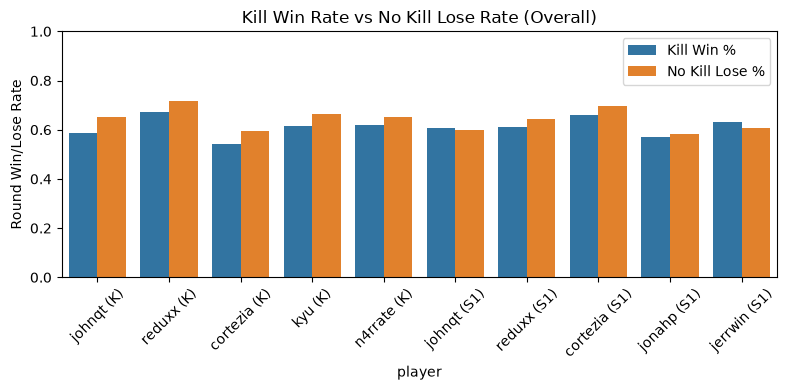

In [ ]:
overall_k = vod_review_df[vod_review_df['event'] == 'amer_kickoff_2026']
overall_s1 = vod_review_df[vod_review_df['event'] == 'amer_stage_1_2026']

rows = []

for pre_col, post_col in players_t_k:
    kill_mask = overall_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = overall_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'Kill Win %': overall_k.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - overall_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_t_s1:
    kill_mask = overall_s1[[pre_col, post_col]].ge(1).any(axis=1) # masks out rounds where x player had at least one kill pre-/post-plant
    no_kill_mask = overall_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1) # masks out rounds where x player had no kills in both pre-/post-plant

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'Kill Win %': overall_s1.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - overall_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['Kill Win %', 'No Kill Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (Overall)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

There are a couple outliers on both ends of the spectrum. First, in kill contribution to winrate, some standout highs are Reduxx during Kickoff, and cortezia during Stage 1, having the most positive impact on the round when getting a kill. Some standout lows for the team are cortezia during Kickoff, and jonahp during Stage 1, contributing lower impact to the team's winrate when getting a kill in the round.

Now in not getting a kill to the team's lose rate, we see the same standout highs and lows.

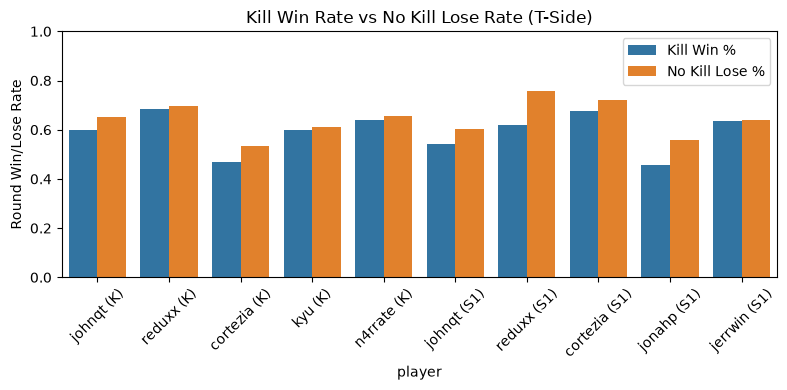

Average T-Side Winrate in Kickoff was 46.81%
Average T-Side Winrate in Stage 1 was 44.93%


In [ ]:
t_side = vod_review_df[(vod_review_df['side'] == 't')]
t_side_k = t_side[t_side['event'] == 'amer_kickoff_2026']
t_side_s1 = t_side[t_side['event'] == 'amer_stage_1_2026']

rows = []

for pre_col, post_col in players_t_k:
    kill_mask = t_side_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = t_side_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'Kill Win %': t_side_k.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - t_side_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_t_s1:
    kill_mask = t_side_s1[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = t_side_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'Kill Win %': t_side_s1.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - t_side_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['Kill Win %', 'No Kill Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (T-Side)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("Average T-Side Winrate in Kickoff was " + str((t_side_k['round_win'].mean() * 100).round(2)) + "%")
print("Average T-Side Winrate in Stage 1 was " + str((t_side_s1['round_win'].mean() * 100).round(2)) + "%")

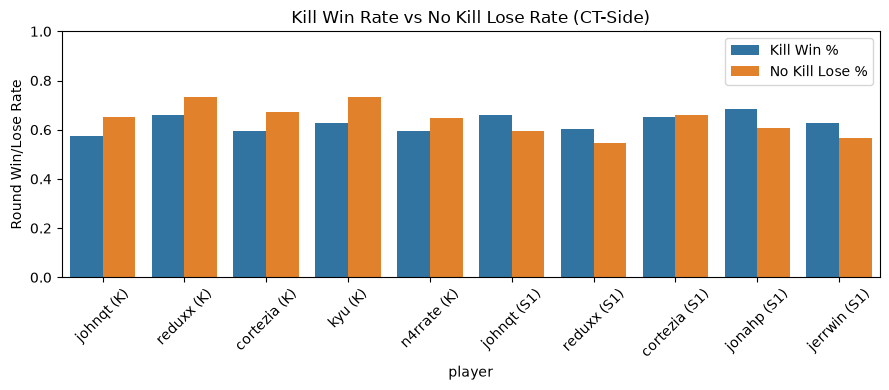

Average CT-Side Winrate in Kickoff was 45.83%
Average CT-Side Winrate in Stage 1 was 52.21%


In [83]:
ct_side = vod_review_df[(vod_review_df['side'] == 'ct')]
ct_side_k = ct_side[ct_side['event'] == 'amer_kickoff_2026']
ct_side_s1 = ct_side[ct_side['event'] == 'amer_stage_1_2026']

rows = []

for pre_col, post_col in players_t_k:
    kill_mask = ct_side_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = ct_side_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'Kill Win %': ct_side_k.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - ct_side_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_t_s1:
    kill_mask = ct_side_s1[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = ct_side_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'Kill Win %': ct_side_s1.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - ct_side_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['Kill Win %', 'No Kill Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (CT-Side)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("Average CT-Side Winrate in Kickoff was " + str((ct_side_k['round_win'].mean() * 100).round(2)) + "%")
print("Average CT-Side Winrate in Stage 1 was " + str((ct_side_s1['round_win'].mean() * 100).round(2)) + "%")

From this, we can see that in Kickoff, the more impactful players in the Pistol rounds were Reduxx, Kyu, and N4RRATE, contributing to higher winrates in the rounds when they got a kill. But Reduxx is the only standout where his lack of a kill impacted the round more than everyone else.

In Stage 1, the more impactful players in the Pistol rounds were johnqt, reduxx, and cortezia, contributing to higher winrates in the rounds when they got a kill. johnqt and cortezia stand out more in the rounds where they didn't get a kill, especially cortezia, SEN loses 100% of the rounds when he doesn't get a kill.  

Now let's take a look at each half instead of pistol rounds, on Attacking (T-Side) and Defending (CT-Side) halves

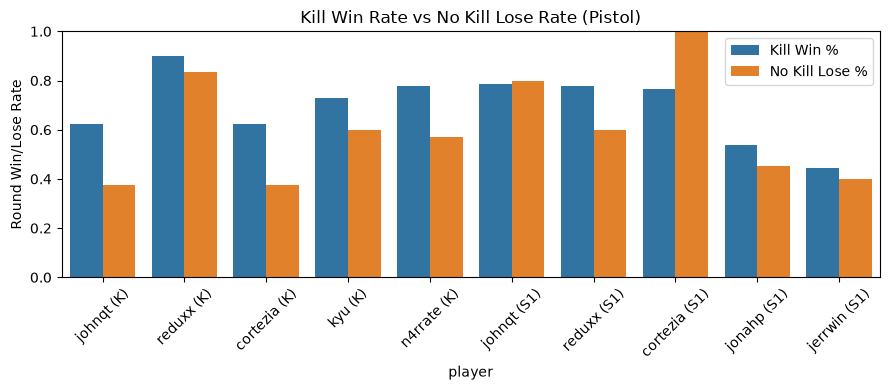

In [84]:
pistols = vod_review_df[(vod_review_df['round'] == 1) | (vod_review_df['round'] == 13)]
pistols_k = pistols[pistols['event'] == 'amer_kickoff_2026']
pistols_s1 = pistols[pistols['event'] == 'amer_stage_1_2026']

rows = []

for pre_col, post_col in players_t_k:
    kill_mask = pistols_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = pistols_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'Kill Win %': pistols_k.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - pistols_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_t_s1:
    kill_mask = pistols_s1[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = pistols_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'Kill Win %': pistols_s1.loc[kill_mask, 'round_win'].mean(),
        'No Kill Lose %': 1 - pistols_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['Kill Win %', 'No Kill Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (Pistol)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

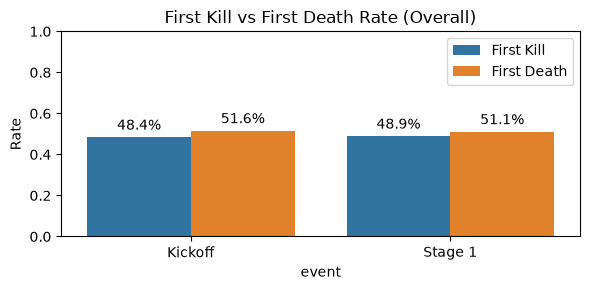

In [79]:
adv_k = overall_k.dropna(subset=['fk_player'])
adv_s1 = overall_s1.dropna(subset=['fk_player'])
disadv_k = overall_k.dropna(subset=['fd_player'])
disadv_s1 = overall_s1.dropna(subset=['fd_player'])

adv_k_r = len(adv_k.index) / len(overall_k.index)
adv_s1_r = len(adv_s1.index) / len(overall_s1.index)
disadv_k_r = len(disadv_k.index) / len(overall_k.index)
disadv_s1_r = len(disadv_s1.index) / len(overall_s1.index)

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['First Kill', 'First Death', 'First Kill', 'First Death'],
    'rate': [adv_k_r, disadv_k_r, adv_s1_r, disadv_s1_r]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Rate')
plt.title('First Kill vs First Death Rate (Overall)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

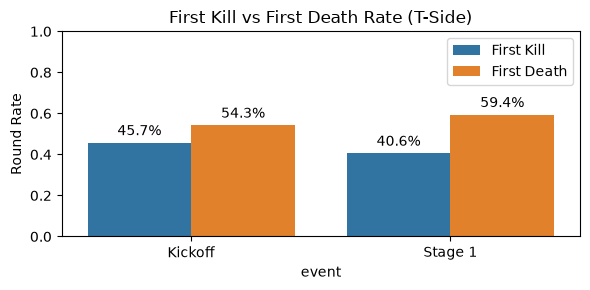

In [80]:
t_adv_k = t_side_k.dropna(subset=['fk_player'])
t_adv_s1 = t_side_s1.dropna(subset=['fk_player'])
t_disadv_k = t_side_k.dropna(subset=['fd_player'])
t_disadv_s1 = t_side_s1.dropna(subset=['fd_player'])

t_adv_k_r = len(t_adv_k.index) / len(t_side_k.index)
t_adv_s1_r = len(t_adv_s1.index) / len(t_side_s1.index)
t_disadv_k_r = len(t_disadv_k.index) / len(t_side_k.index)
t_disadv_s1_r = len(t_disadv_s1.index) / len(t_side_s1.index)

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['First Kill', 'First Death', 'First Kill', 'First Death'],
    'rate': [t_adv_k_r, t_disadv_k_r, t_adv_s1_r, t_disadv_s1_r]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Rate')
plt.title('First Kill vs First Death Rate (T-Side)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

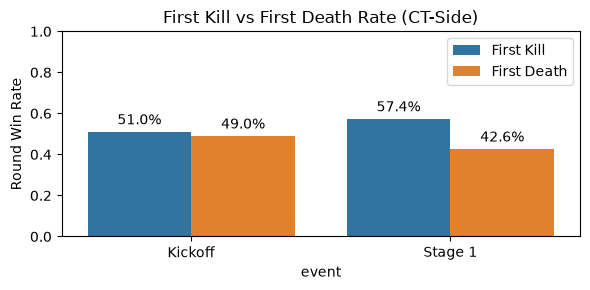

In [81]:
ct_adv_k = ct_side_k.dropna(subset=['fk_player'])
ct_adv_s1 = ct_side_s1.dropna(subset=['fk_player'])
ct_disadv_k = ct_side_k.dropna(subset=['fd_player'])
ct_disadv_s1 = ct_side_s1.dropna(subset=['fd_player'])

ct_adv_k_r = len(ct_adv_k.index) / len(ct_side_k.index)
ct_adv_s1_r = len(ct_adv_s1.index) / len(ct_side_s1.index)
ct_disadv_k_r = len(ct_disadv_k.index) / len(ct_side_k.index)
ct_disadv_s1_r = len(ct_disadv_s1.index) / len(ct_side_s1.index)

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['First Kill', 'First Death', 'First Kill', 'First Death'],
    'rate': [ct_adv_k_r, ct_disadv_k_r, ct_adv_s1_r, ct_disadv_s1_r]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Win Rate')
plt.title('First Kill vs First Death Rate (CT-Side)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

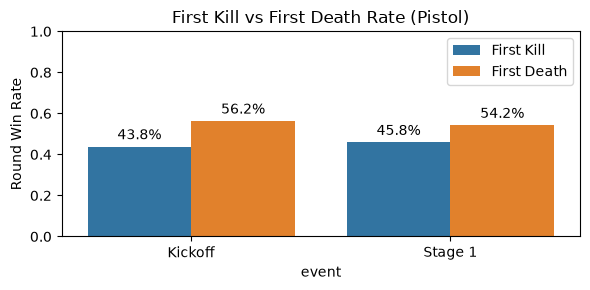

In [82]:
p_adv_k = pistols_k.dropna(subset=['fk_player'])
p_adv_s1 = pistols_s1.dropna(subset=['fk_player'])
p_disadv_k = pistols_k.dropna(subset=['fd_player'])
p_disadv_s1 = pistols_s1.dropna(subset=['fd_player'])

p_adv_k_r = len(p_adv_k.index) / len(pistols_k.index)
p_adv_s1_r = len(p_adv_s1.index) / len(pistols_s1.index)
p_disadv_k_r = len(p_disadv_k.index) / len(pistols_k.index)
p_disadv_s1_r = len(p_disadv_s1.index) / len(pistols_s1.index)

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['First Kill', 'First Death', 'First Kill', 'First Death'],
    'rate': [p_adv_k_r, p_disadv_k_r, p_adv_s1_r, p_disadv_s1_r]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Win Rate')
plt.title('First Kill vs First Death Rate (Pistol)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

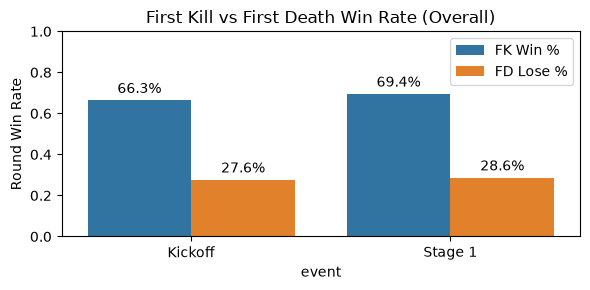

In [75]:
adv_k_wr = adv_k['round_win'].mean()
adv_s1_wr = adv_s1['round_win'].mean()
disadv_k_wr = disadv_k['round_win'].mean()
disadv_s1_wr = disadv_s1['round_win'].mean()

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['FK Win %', 'FD Lose %', 'FK Win %', 'FD Lose %'],
    'win_rate': [adv_k_wr, disadv_k_wr, adv_s1_wr, disadv_s1_wr]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='win_rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Win Rate')
plt.title('First Kill vs First Death Win Rate (Overall)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

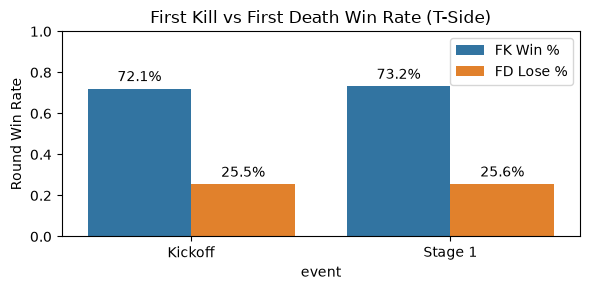

In [73]:
t_adv_k_wr = t_adv_k['round_win'].mean()
t_adv_s1_wr = t_adv_s1['round_win'].mean()
t_disadv_k_wr = t_disadv_k['round_win'].mean()
t_disadv_s1_wr = t_disadv_s1['round_win'].mean()

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['FK Win %', 'FD Lose %', 'FK Win %', 'FD Lose %'],
    'win_rate': [t_adv_k_wr, t_disadv_k_wr, t_adv_s1_wr, t_disadv_s1_wr]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='win_rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Win Rate')
plt.title('First Kill vs First Death Win Rate (T-Side)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

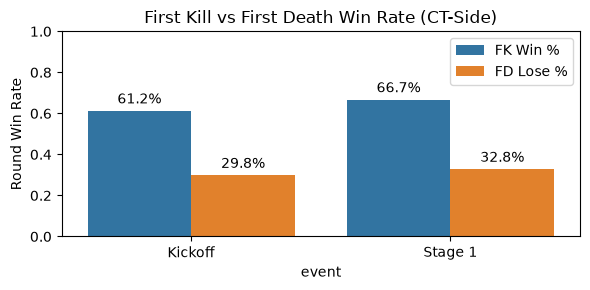

In [95]:
ct_adv_k = ct_side_k.dropna(subset=['fk_player'])
ct_adv_s1 = ct_side_s1.dropna(subset=['fk_player'])
ct_disadv_k = ct_side_k.dropna(subset=['fd_player'])
ct_disadv_s1 = ct_side_s1.dropna(subset=['fd_player'])

ct_adv_k_wr = ct_adv_k['round_win'].mean()
ct_adv_s1_wr = ct_adv_s1['round_win'].mean()
ct_disadv_k_wr = ct_disadv_k['round_win'].mean()
ct_disadv_s1_wr = ct_disadv_s1['round_win'].mean()

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['FK Win %', 'FD Lose %', 'FK Win %', 'FD Lose %'],
    'win_rate': [ct_adv_k_wr, ct_disadv_k_wr, ct_adv_s1_wr, ct_disadv_s1_wr]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='win_rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Win Rate')
plt.title('First Kill vs First Death Win Rate (CT-Side)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

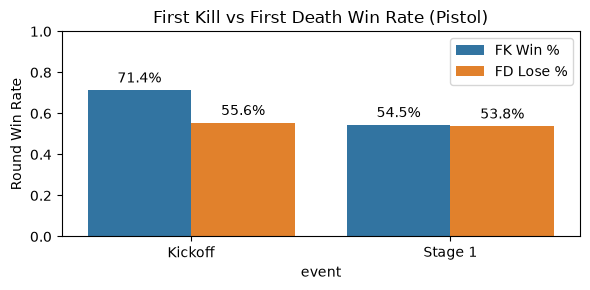

In [71]:
p_adv_k = pistols_k.dropna(subset=['fk_player'])
p_adv_s1 = pistols_s1.dropna(subset=['fk_player'])
p_disadv_k = pistols_k.dropna(subset=['fd_player'])
p_disadv_s1 = pistols_s1.dropna(subset=['fd_player'])

p_adv_k_wr = p_adv_k['round_win'].mean()
p_adv_s1_wr = p_adv_s1['round_win'].mean()
p_disadv_k_wr = p_disadv_k['round_win'].mean()
p_disadv_s1_wr = p_disadv_s1['round_win'].mean()

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['FK Win %', 'FD Lose %', 'FK Win %', 'FD Lose %'],
    'win_rate': [p_adv_k_wr, p_disadv_k_wr, p_adv_s1_wr, p_disadv_s1_wr]
})

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=plot_df, x='event', y='win_rate', hue='side')
for container in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ylabel('Round Win Rate')
plt.title('First Kill vs First Death Win Rate (Pistol)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

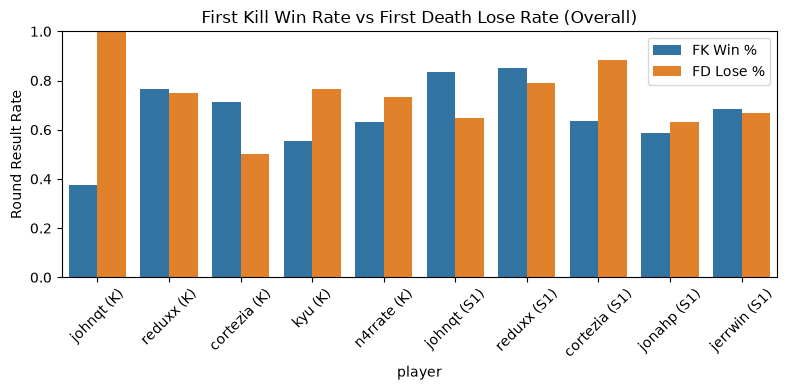

In [85]:
first_kd_k = vod_review_df[vod_review_df['event'] == 'amer_kickoff_2026']
first_kd_s1 = vod_review_df[vod_review_df['event'] == 'amer_stage_1_2026']

rows = []

for player in players_l_k:
    rows.append({
        'player': f'{player} (K)',
        'FK Win %': first_kd_k.loc[
            first_kd_k['fk_player'] == player,
            'round_win'
        ].mean(),
        'FD Lose %': 1 - first_kd_k.loc[
            first_kd_k['fd_player'] == player,
            'round_win'
        ].mean()
    })

for player in players_l_s1:
    rows.append({
        'player': f'{player} (S1)',
        'FK Win %': first_kd_s1.loc[
            first_kd_s1['fk_player'] == player,
            'round_win'
        ].mean(),
        'FD Lose %': 1 - first_kd_s1.loc[
            first_kd_s1['fd_player'] == player,
            'round_win'
        ].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['FK Win %', 'FD Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)
plt.ylabel('Round Result Rate')
plt.title('First Kill Win Rate vs First Death Lose Rate (Overall)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

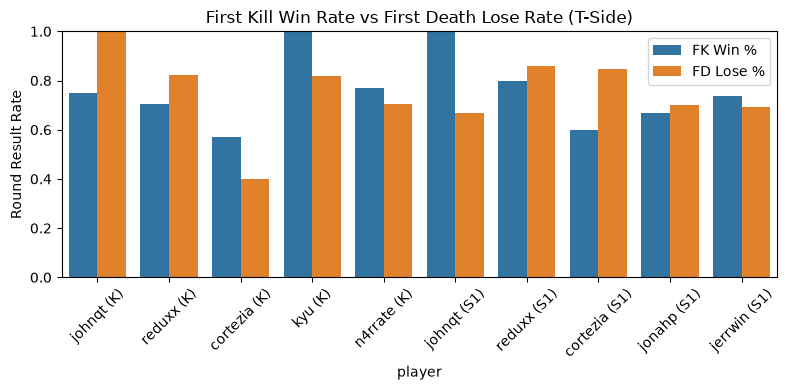

In [86]:
fkd_t_k = first_kd_k[first_kd_k['side'] == 't']
fkd_t_s1 = first_kd_s1[first_kd_s1['side'] == 't']

rows = []

for player in players_l_k:
    rows.append({
        'player': f'{player} (K)',
        'FK Win %': fkd_t_k.loc[
            fkd_t_k['fk_player'] == player,
            'round_win'
        ].mean(),
        'FD Lose %': 1 - fkd_t_k.loc[
            fkd_t_k['fd_player'] == player,
            'round_win'
        ].mean()
    })

for player in players_l_s1:
    rows.append({
        'player': f'{player} (S1)',
        'FK Win %': fkd_t_s1.loc[
            fkd_t_s1['fk_player'] == player,
            'round_win'
        ].mean(),
        'FD Lose %': 1 - fkd_t_s1.loc[
            fkd_t_s1['fd_player'] == player,
            'round_win'
        ].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['FK Win %', 'FD Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)
plt.ylabel('Round Result Rate')
plt.title('First Kill Win Rate vs First Death Lose Rate (T-Side)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

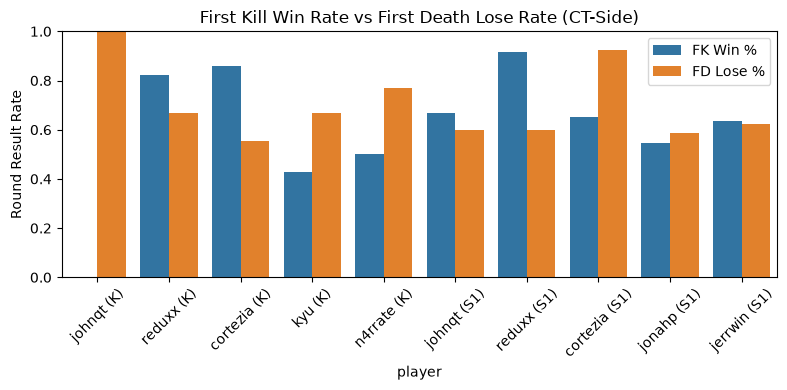

In [87]:
fkd_ct_k = first_kd_k[first_kd_k['side'] == 'ct']
fkd_ct_s1 = first_kd_s1[first_kd_s1['side'] == 'ct']

rows = []

for player in players_l_k:
    rows.append({
        'player': f'{player} (K)',
        'FK Win %': fkd_ct_k.loc[
            fkd_ct_k['fk_player'] == player,
            'round_win'
        ].mean(),
        'FD Lose %': 1 - fkd_ct_k.loc[
            fkd_ct_k['fd_player'] == player,
            'round_win'
        ].mean()
    })

for player in players_l_s1:
    rows.append({
        'player': f'{player} (S1)',
        'FK Win %': fkd_ct_s1.loc[
            fkd_ct_s1['fk_player'] == player,
            'round_win'
        ].mean(),
        'FD Lose %': 1 - fkd_ct_s1.loc[
            fkd_ct_s1['fd_player'] == player,
            'round_win'
        ].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['FK Win %', 'FD Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)
plt.ylabel('Round Result Rate')
plt.title('First Kill Win Rate vs First Death Lose Rate (CT-Side)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

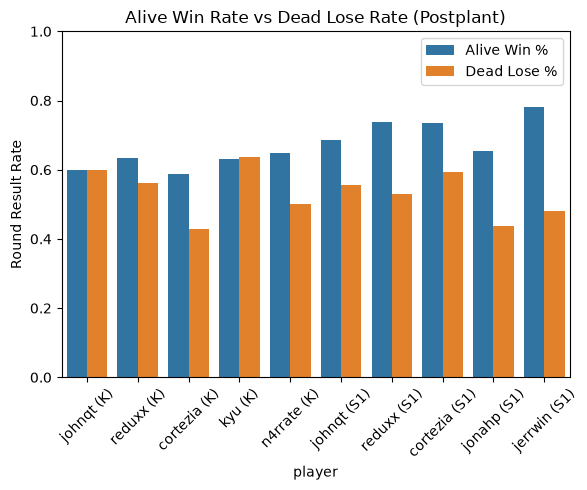

Average Postplant Winrate Kickoff: 0.5846153846153846%
Average Postplant Winrate Stage 1: 0.6373626373626373%


In [89]:
post_plant_k = t_side_k[(t_side_k['spike_planted'] == 1)]
post_plant_s1 = t_side_s1[(t_side_s1['spike_planted'] == 1)]

rows = []

for player in players_l_k:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (K)',
        'Alive Win %': post_plant_k.loc[post_plant_k[col].notna(), 'round_win'].mean(),
        'Dead Lose %': 1 - post_plant_k.loc[post_plant_k[col].isna(), 'round_win'].mean()
    })

for player in players_l_s1:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (S1)',
        'Alive Win %': post_plant_s1.loc[post_plant_s1[col].notna(), 'round_win'].mean(),
        'Dead Lose %': 1 - post_plant_s1.loc[post_plant_s1[col].isna(), 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['Alive Win %', 'Dead Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(6, 5))
sns.barplot(data=plot_df_long, x='player', y='rate', hue='side')
plt.ylabel('Round Result Rate')
plt.title('Alive Win Rate vs Dead Lose Rate (Postplant)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Average Postplant Winrate Kickoff: " + str(post_plant_k['round_win'].mean()) +"%")
print("Average Postplant Winrate Stage 1: " + str(post_plant_s1['round_win'].mean()) +"%")

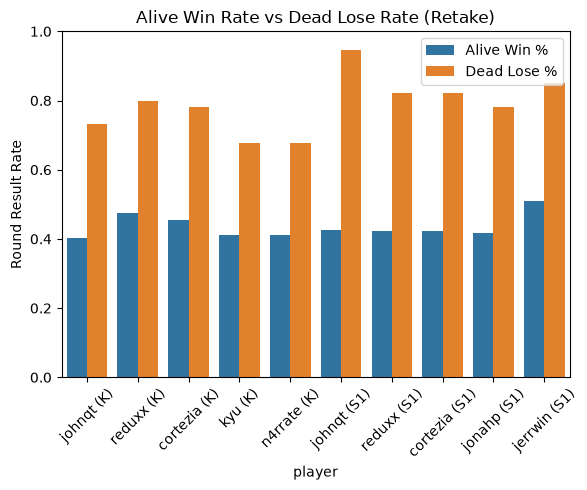

Average Retake Winrate Kickoff: 0.373134328358209%
Average Retake Winrate Stage 1: 0.3448275862068966%


In [66]:
retake_k = ct_side_k[(ct_side_k['spike_planted'] == 1)]
retake_s1 = ct_side_s1[(ct_side_s1['spike_planted'] == 1)]

rows = []

for player in players_l_k:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (K)',
        'Alive Win %': retake_k.loc[retake_k[col].notna(), 'round_win'].mean(),
        'Dead Lose %': 1 - retake_k.loc[retake_k[col].isna(), 'round_win'].mean()
    })

for player in players_l_s1:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (S1)',
        'Alive Win %': retake_s1.loc[retake_s1[col].notna(), 'round_win'].mean(),
        'Dead Lose %': 1 - retake_s1.loc[retake_s1[col].isna(), 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['Alive Win %', 'Dead Lose %'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(6, 5))
sns.barplot(data=plot_df_long, x='player', y='rate', hue='side')
plt.ylabel('Round Result Rate')
plt.title('Alive Win Rate vs Dead Lose Rate (Retake)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Average Retake Winrate Kickoff: " + str(retake_k['round_win'].mean()) +"%")
print("Average Retake Winrate Stage 1: " + str(retake_s1['round_win'].mean()) +"%")

In [28]:
print("Average First Kill/Death Kickoff: " + str(t_side_k['fk_time'].mean()))
print("Average First Kill/Death Stage 1: " + str(t_side_s1['fk_time'].mean()))

Average First Kill/Death Kickoff: 29.861702127659573
Average First Kill/Death Stage 1: 30.840579710144926


In [29]:
print("Average First Kill/Death Kickoff: " + str(ct_side_k['fk_time'].mean()))
print("Average First Kill/Death Stage 1: " + str(ct_side_s1['fk_time'].mean()))

Average First Kill/Death Kickoff: 34.510416666666664
Average First Kill/Death Stage 1: 31.558823529411764


In [30]:
print("Average Plant Time Kickoff: " + str(t_side_k['plant_time'].mean()))
print("Average Plant Time Stage 1: " + str(t_side_s1['plant_time'].mean()))

Average Plant Time Kickoff: 56.56923076923077
Average Plant Time Stage 1: 58.46153846153846


In [31]:
print("Average Plant Rate Kickoff: " + str(t_side_k['spike_planted'].mean()))
print("Average Plant Rate Stage 1: " + str(t_side_s1['spike_planted'].mean()))

Average Plant Rate Kickoff: 0.7065217391304348
Average Plant Rate Stage 1: 0.6594202898550725


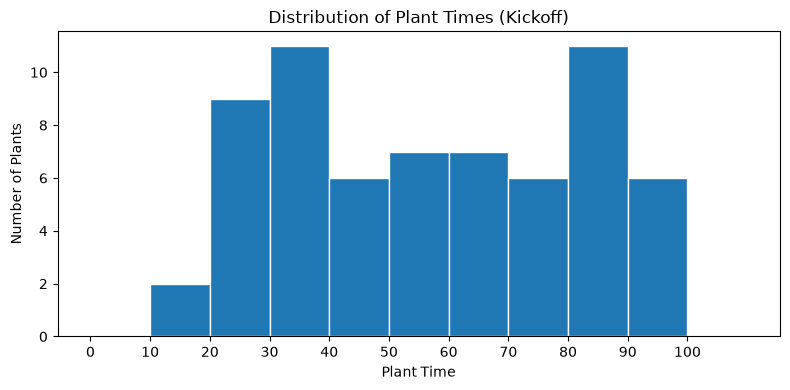

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(post_plant_k["plant_time"], bins=range(0, 111, 10), edgecolor="white")
plt.xlabel("Plant Time")
plt.ylabel("Number of Plants")
plt.title("Distribution of Plant Times (Kickoff)")
plt.xticks(range(0, 101, 10))
plt.tight_layout()
plt.show()

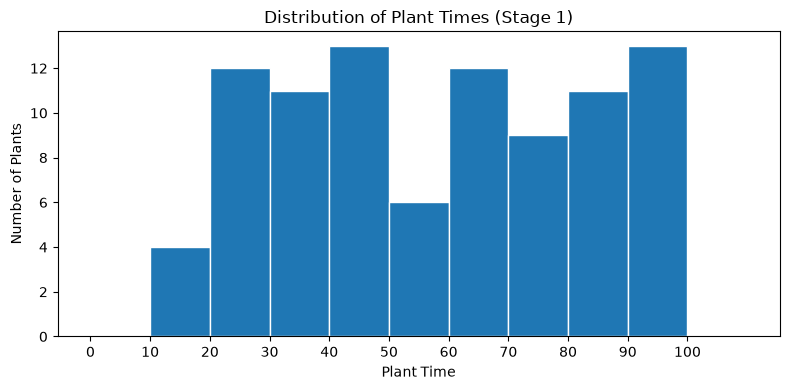

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(post_plant_s1["plant_time"], bins=range(0, 111, 10), edgecolor="white")
plt.xlabel("Plant Time")
plt.ylabel("Number of Plants")
plt.title("Distribution of Plant Times (Stage 1)")
plt.xticks(range(0, 101, 10))
plt.tight_layout()
plt.show()

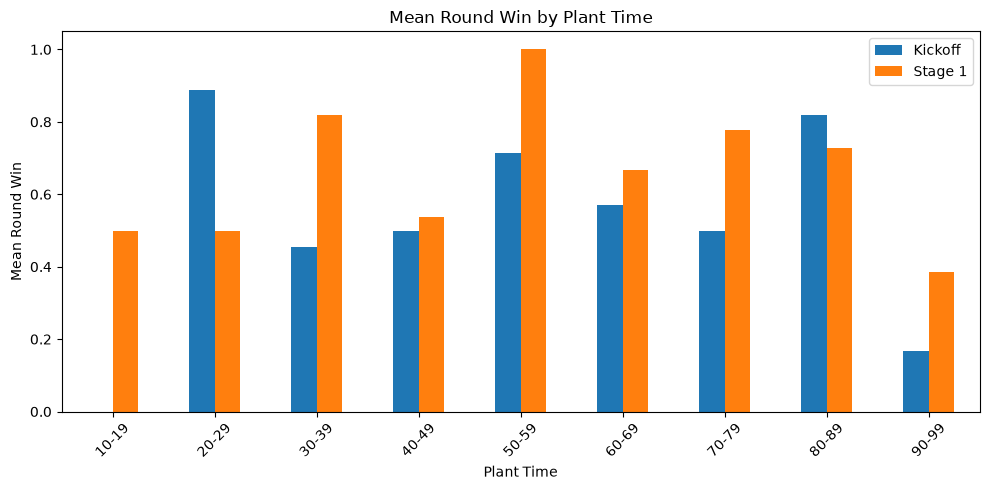

In [94]:
def binned_means_plant(df):
    bins = range(0, 111, 10)
    labels = [f"{i}-{i+9}" for i in range(0, 100, 10)] + ["100"]

    df = df.copy()
    df["plant_bin"] = pd.cut(
        df["plant_time"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False
    )

    return df.groupby("plant_bin", observed=True)["round_win"].mean()

comparison = pd.DataFrame({
    "Kickoff": binned_means_plant(post_plant_k),
    "Stage 1": binned_means_plant(post_plant_s1)
})

comparison.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Mean Round Win")
plt.xlabel("Plant Time")
plt.title("Mean Round Win by Plant Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

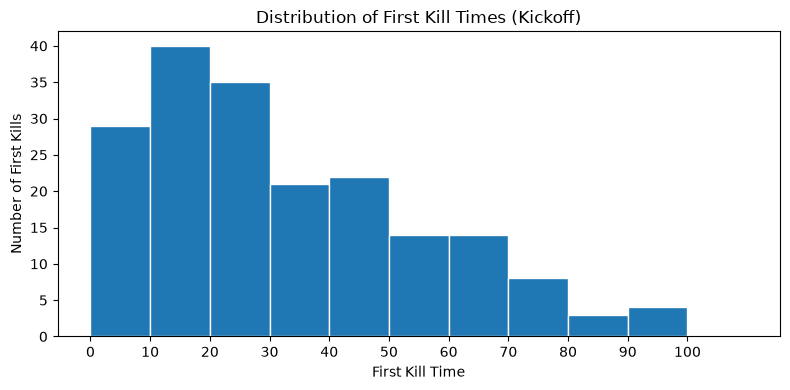

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(overall_k['fk_time'], bins=range(0, 111, 10), edgecolor="white")
plt.xlabel("First Kill Time")
plt.ylabel("Number of First Kills")
plt.title("Distribution of First Kill Times (Kickoff)")
plt.xticks(range(0, 101, 10))
plt.tight_layout()
plt.show()

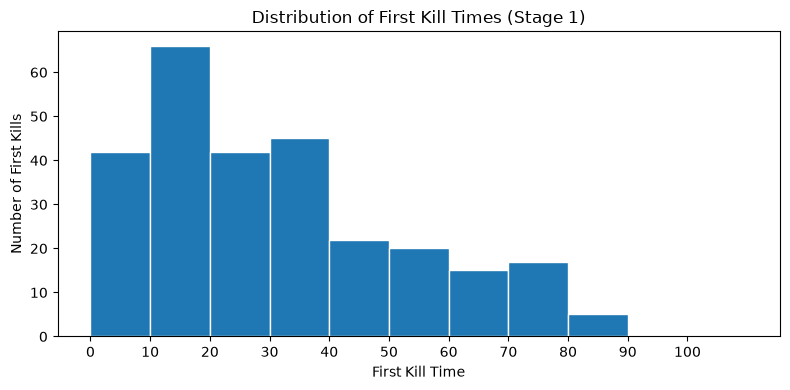

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(overall_s1['fk_time'], bins=range(0, 111, 10), edgecolor="white")
plt.xlabel("First Kill Time")
plt.ylabel("Number of First Kills")
plt.title("Distribution of First Kill Times (Stage 1)")
plt.xticks(range(0, 101, 10))
plt.tight_layout()
plt.show()

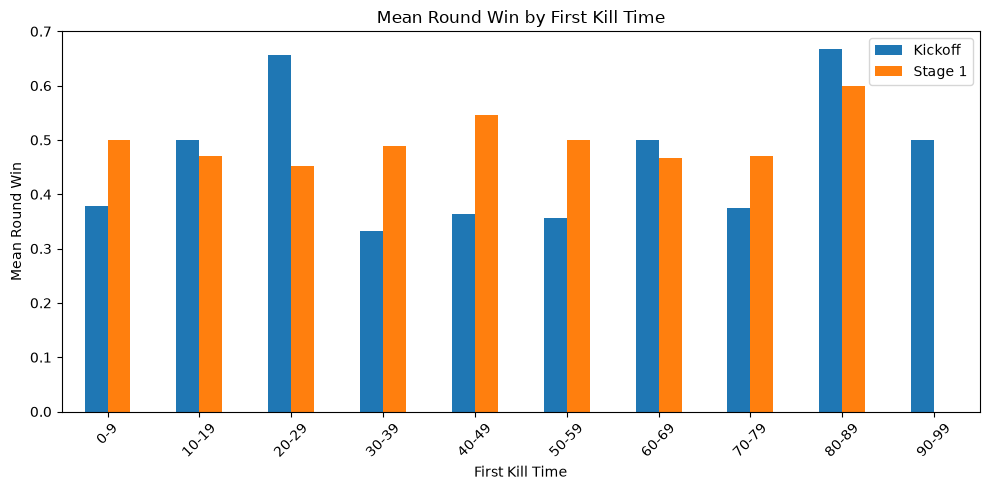

In [93]:
def binned_means_kill(df):
    bins = range(0, 111, 10)
    labels = [f"{i}-{i+9}" for i in range(0, 100, 10)] + ["100"]

    df = df.copy()
    df["plant_bin"] = pd.cut(
        df["fk_time"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False
    )

    return df.groupby("plant_bin", observed=True)["round_win"].mean()

comparison = pd.DataFrame({
    "Kickoff": binned_means_kill(overall_k),
    "Stage 1": binned_means_kill(overall_s1)
})

comparison.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Mean Round Win")
plt.xlabel("First Kill Time")
plt.title("Mean Round Win by First Kill Time")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()